In [4]:
from __future__ import annotations
import numpy as np
from typing import Dict, Tuple, List, Optional

# ---------------- Fast Walsh–Hadamard transform helpers ----------------
def fwht_inplace(x: np.ndarray) -> np.ndarray:
    """In-place FWHT on the last axis (length power of 2)."""
    n = x.shape[-1]
    h = 1
    while h < n:
        xr = x.reshape(*x.shape[:-1], n // (2*h), 2, h)
        a = xr[..., 0, :].copy()   # copies avoid aliasing
        b = xr[..., 1, :].copy()
        xr[..., 0, :] = a + b
        xr[..., 1, :] = a - b
        h *= 2
    return x

def fwht_vec(v: np.ndarray) -> np.ndarray:
    x = v.copy()[None, :]
    fwht_inplace(x)
    return x[0]

# ---------------- Bit helpers ----------------
def popcount_u64(x: np.ndarray | int) -> np.ndarray | int:
    if isinstance(x, int):
        x &= (1 << 64) - 1
        x = np.uint64(x)
    v = x.astype(np.uint64)
    v = v - ((v >> 1) & np.uint64(0x5555555555555555))
    v = (v & np.uint64(0x3333333333333333)) + ((v >> 2) & np.uint64(0x3333333333333333))
    v = (v + (v >> 4)) & np.uint64(0x0F0F0F0F0F0F0F0F)
    v = v + (v >> 8); v = v + (v >> 16); v = v + (v >> 32)
    return (v & np.uint64(0x7F)).astype(np.int64)

# ---------------- Pauli decomposition (sparse, streaming) ----------------
def iter_pauli_coeffs_fwht(A: np.ndarray, tau: float = 0.0):
    """
    Stream (r, s, alpha_rs) for |alpha| > tau using the FWHT method.
    """
    A = np.asarray(A, dtype=complex)
    N = A.shape[0]; assert A.shape == (N, N)
    n = int(round(np.log2(N))); assert (1 << n) == N
    qs = np.arange(N, dtype=np.int64)
    scale = 1.0 / (2**n)

    # vectorized popcount over r & s
    def phaserow(r: int) -> np.ndarray:
        wt = popcount_u64((r & qs))
        return (1j) ** (-wt)

    for r in range(N):
        b = A[np.bitwise_xor(qs, r), qs]
        t = fwht_vec(b)
        phase = phaserow(r)
        row = (phase * t) * scale
        # threshold streaming
        nz = np.where(np.abs(row) > tau)[0]
        for s in nz:
            yield r, int(s), row[s]

def pauli_sparse(A: np.ndarray, tau: float = 0.0) -> Dict[Tuple[int,int], complex]:
    out: Dict[Tuple[int,int], complex] = {}
    for r, s, a in iter_pauli_coeffs_fwht(A, tau):
        out[(int(r), int(s))] = a
    return out

# ---------------- Cost / histogram ----------------
def weight_hist_from_alpha(alpha: Dict[Tuple[int,int], complex], n: int) -> Dict[int, float]:
    """Return {weight -> mass} where mass = sum |alpha|^2 for that weight."""
    hist: Dict[int, float] = {}
    for (r, s), a in alpha.items():
        w = int(popcount_u64((r | s)))
        hist[w] = hist.get(w, 0.0) + float(np.abs(a)**2)
    return hist

def high_weight_cost_from_alpha(alpha: Dict[Tuple[int,int], complex], k_hi: int) -> float:
    c = 0.0
    for (r, s), a in alpha.items():
        if int(popcount_u64(r | s)) >= k_hi:
            c += float(np.abs(a)**2)
    return c

# ---------------- Linear reorderings: x -> A x (mod 2) ----------------
class LinGF2:
    """Invertible n×n binary map with fast action on bit-int via row masks; keeps A and B = A^{-T}."""
    def __init__(self, n: int):
        self.n = n
        self.A_row_masks = [(1 << j) for j in range(n)]  # identity
        self.B_col_masks = [(1 << j) for j in range(n)]  # identity

    def copy_from(self, other: 'LinGF2'):
        self.n = other.n
        self.A_row_masks = other.A_row_masks.copy()
        self.B_col_masks = other.B_col_masks.copy()

    def apply_A(self, r: int) -> int:
        out = 0
        for j in range(self.n):
            if popcount_u64(r & self.A_row_masks[j]) & 1:
                out |= (1 << j)
        return out

    def apply_B(self, s: int) -> int:
        out = 0
        for k in range(self.n):
            if (s >> k) & 1:
                out ^= self.B_col_masks[k]
        return out

    def row_swap(self, i: int, j: int):
        self.A_row_masks[i], self.A_row_masks[j] = self.A_row_masks[j], self.A_row_masks[i]
        self.B_col_masks[i], self.B_col_masks[j] = self.B_col_masks[j], self.B_col_masks[i]

    def row_xor(self, i: int, j: int):  # row j ^= row i
        if i == j: return
        self.A_row_masks[j] ^= self.A_row_masks[i]
        self.B_col_masks[j] ^= self.B_col_masks[i]

def cost_under_linear(alpha: Dict[Tuple[int,int], complex], n: int, A: LinGF2, k_hi: int) -> float:
    """Compute high-weight mass after linear reordering without recomputing FWHT."""
    c = 0.0
    for (r, s), a in alpha.items():
        rp = A.apply_A(r)
        sp = A.apply_B(s)
        if int(popcount_u64(rp | sp)) >= k_hi:
            c += float(np.abs(a)**2)
    return c

def optimize_linear(alpha: Dict[Tuple[int,int], complex], n: int, k_hi: int,
                    iters: int = 20000, temp0: float = 1.0, temp_final: float = 0.01, seed: int = 0) -> LinGF2:
    rng = np.random.default_rng(seed)
    cur = LinGF2(n)
    best = LinGF2(n); best.copy_from(cur)
    cur_cost = cost_under_linear(alpha, n, cur, k_hi)
    best_cost = cur_cost

    for t in range(iters):
        T = temp0 * (temp_final / temp0) ** (t / max(1, iters-1))
        savedA = cur.A_row_masks.copy()
        savedB = cur.B_col_masks.copy()

        # propose random generator
        if rng.random() < 0.5:
            i, j = rng.integers(0, n), rng.integers(0, n)
            while j == i:
                j = rng.integers(0, n)
            cur.row_swap(int(i), int(j))
        else:
            i, j = rng.integers(0, n), rng.integers(0, n)
            while j == i:
                j = rng.integers(0, n)
            cur.row_xor(int(i), int(j))

        new_cost = cost_under_linear(alpha, n, cur, k_hi)
        delta = new_cost - cur_cost
        if delta <= 0 or rng.random() < np.exp(-delta / max(T, 1e-12)):
            cur_cost = new_cost
            if new_cost < best_cost:
                best_cost = new_cost
                best.copy_from(cur)
        else:
            cur.A_row_masks = savedA
            cur.B_col_masks = savedB

    return best

def permutation_from_linear(A_lin: LinGF2) -> np.ndarray:
    """Return permutation p of length 2^n: new matrix is A[p][:, p]."""
    n = A_lin.n
    N = 1 << n
    p = np.empty(N, dtype=np.int64)
    for i in range(N):
        p[i] = A_lin.apply_A(i)  # rank = integer of Ax
    return p

# ---------------- Nonlinear sampled orderings (Gray etc.) ----------------
def gray_of_int(i: int) -> int:
    return i ^ (i >> 1)

def gray_permutation(n: int) -> np.ndarray:
    N = 1 << n
    return np.fromiter((gray_of_int(i) for i in range(N)), count=N, dtype=np.int64)

def apply_permutation(A: np.ndarray, p: np.ndarray) -> np.ndarray:
    return A[np.ix_(p, p)]

def evaluate_permutation(A: np.ndarray, k_hi: int, tau: float, p: np.ndarray) -> Tuple[float, Dict[int, float]]:
    Aperm = apply_permutation(A, p)
    alpha = pauli_sparse(Aperm, tau=tau)
    n = int(np.log2(A.shape[0]))
    cost = high_weight_cost_from_alpha(alpha, k_hi=k_hi)
    hist = weight_hist_from_alpha(alpha, n)
    return cost, hist

# ---------------- Top-level: optimize ordering ----------------
def optimize_bitstring_ordering(A: np.ndarray,
                                k_hi: int = 3,
                                tau: float = 0.0,
                                linear_iters: int = 20000,
                                try_gray: bool = True,
                                try_gray_composed: bool = True,
                                random_nonlin: int = 0,
                                seed: int = 0):
    """
    Returns:
      best_p: np.ndarray permutation for rows/cols
      report: dict with 'cost', 'hist', 'mode' and comparisons
    """
    N = A.shape[0]; n = int(round(np.log2(N))); assert (1 << n) == N

    # 1) Decompose once in the current (binary) order
    alpha0 = pauli_sparse(A, tau=tau)
    base_cost = high_weight_cost_from_alpha(alpha0, k_hi=k_hi)
    hist0 = weight_hist_from_alpha(alpha0, n)

    # 2) Linear search (fast, no recompute)
    A_lin = optimize_linear(alpha0, n, k_hi=k_hi, iters=linear_iters, seed=seed)
    p_lin = permutation_from_linear(A_lin)
    lin_cost = cost_under_linear(alpha0, n, A_lin, k_hi=k_hi)
    # also compute a histogram under linear map by relabeling weights
    hist_lin: Dict[int, float] = {}
    for (r, s), a in alpha0.items():
        rp, sp = A_lin.apply_A(r), A_lin.apply_B(s)
        w = int(popcount_u64(rp | sp))
        hist_lin[w] = hist_lin.get(w, 0.0) + float(np.abs(a)**2)

    best_p = p_lin
    best_cost = lin_cost
    best_hist = hist_lin
    best_mode = "linear"

    # 3) Sample a few nonlinear permutations (expensive)
    rng = np.random.default_rng(seed)
    if try_gray:
        p_gray = gray_permutation(n)
        cost_g, hist_g = evaluate_permutation(A, k_hi, tau, p_gray)
        if cost_g < best_cost:
            best_p, best_cost, best_hist, best_mode = p_gray, cost_g, hist_g, "gray"

    if try_gray_composed:
        # Gray ∘ A  and  A ∘ Gray
        pA = p_lin
        p_gray = gray_permutation(n)
        # compose permutations: p2∘p1 means p_comp[i] = p2[p1[i]]
        p_gray_after_A = p_gray[pA]
        p_A_after_gray = pA[p_gray]
        for tag, pcand in [("gray∘linear", p_gray_after_A), ("linear∘gray", p_A_after_gray)]:
            cost_c, hist_c = evaluate_permutation(A, k_hi, tau, pcand)
            if cost_c < best_cost:
                best_p, best_cost, best_hist, best_mode = pcand, cost_c, hist_c, tag

    for t in range(random_nonlin):
        pcand = rng.permutation(N)
        cost_c, hist_c = evaluate_permutation(A, k_hi, tau, pcand)
        if cost_c < best_cost:
            best_p, best_cost, best_hist, best_mode = pcand, cost_c, hist_c, f"random-{t}"

    report = {
        "mode": best_mode,
        "base_cost": base_cost,
        "base_hist": hist0,
        "best_cost": best_cost,
        "best_hist": best_hist,
    }
    return best_p, report

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List, Optional

# ---------------- Pauli weights & summaries ----------------
def pauli_weight_hist_from_rs(alpha: Dict[Tuple[int,int], complex],
                              n: Optional[int] = None,
                              use_counts: bool = False) -> Dict[int, float]:
    """
    Given {(r,s): alpha}, return {weight -> mass} where mass = sum |alpha|^2 at that weight.
    If use_counts=True, returns counts instead of mass.
    Weight = popcount(r | s).
    """
    if n is None:
        # best-effort infer
        N = max(max(r, s) for (r, s) in alpha.keys()) + 1
        n = int(np.ceil(np.log2(N)))
    hist: Dict[int, float] = {}
    for (r, s), a in alpha.items():
        w = int((bin((r | s))).count("1"))
        val = 1.0 if use_counts else float(abs(a)**2)
        hist[w] = hist.get(w, 0.0) + val
    # fill missing weights up to n for convenience
    for w in range(0, n+1):
        hist.setdefault(w, 0.0)
    return dict(sorted(hist.items()))

def pauli_weight_hist_from_strings(coeffs: Dict[str, complex],
                                   use_counts: bool = False) -> Dict[int, float]:
    """
    If you have {'XIZY...': coeff} style, this computes the same histogram.
    """
    hist: Dict[int, float] = {}
    n = None
    for s, a in coeffs.items():
        n = len(s) if n is None else n
        w = sum(ch != 'I' for ch in s)
        val = 1.0 if use_counts else float(abs(a)**2)
        hist[w] = hist.get(w, 0.0) + val
    if n is not None:
        for w in range(0, n+1):
            hist.setdefault(w, 0.0)
    return dict(sorted(hist.items()))

def pauli_weight_summary(alpha: Dict[Tuple[int,int], complex],
                         n: Optional[int] = None) -> str:
    """
    Pretty summary: counts, mass, and cumulative mass by weight.
    """
    hist_mass = pauli_weight_hist_from_rs(alpha, n=n, use_counts=False)
    hist_cnt  = pauli_weight_hist_from_rs(alpha, n=n, use_counts=True)
    total_mass = sum(hist_mass.values()) or 1.0
    lines = ["w | count | mass | frac"]
    cum = 0.0
    for w in sorted(hist_mass):
        mass = hist_mass[w]
        cnt = int(hist_cnt[w])
        frac = mass / total_mass
        cum += frac
        lines.append(f"{w:>1} | {cnt:>5d} | {mass:9.3e} | {frac:6.2%} (cum {cum:6.2%})")
    return "\n".join(lines)

def topk_paulis_from_rs(alpha: Dict[Tuple[int,int], complex], k: int = 50) -> List[Tuple[Tuple[int,int], complex, int]]:
    """
    Return top-k |alpha| with their weights: [((r,s), alpha, weight), ...]
    """
    items = [((r,s), a, int(bin(r|s).count("1"))) for (r,s), a in alpha.items()]
    idx = np.argpartition([-abs(a) for _, a, _ in items], min(k, len(items))-1)[:k]
    subset = [items[i] for i in idx]
    subset.sort(key=lambda t: -abs(t[1]))
    return subset

# ---------------- Plotting the matrix ----------------
def plot_matrix(M: np.ndarray,
                mode: str = "abs",   # 'abs' | 'real' | 'imag' | 'phase'
                perm: Optional[np.ndarray] = None,
                title: Optional[str] = None,
                vmin: Optional[float] = None,
                vmax: Optional[float] = None,
                show_colorbar: bool = True,
                dpi: int = 120):
    """
    Quick heatmap for an NxN (complex) matrix.
    - mode='abs' shows |M|, 'real' shows Re, 'imag' shows Im, 'phase' shows angle in [-π, π].
    - perm: optional permutation of indices; plots M[perm][:, perm].
    - vmin/vmax: optional color scaling.
    """
    A = M if perm is None else M[np.ix_(perm, perm)]
    if mode == "abs":
        Z = np.abs(A)
    elif mode == "real":
        Z = np.real(A)
    elif mode == "imag":
        Z = np.imag(A)
    elif mode == "phase":
        # values in [-pi, pi]
        Z = np.angle(A)
    else:
        raise ValueError("mode must be one of: 'abs','real','imag','phase'")

    plt.figure(dpi=dpi)
    im = plt.imshow(Z, origin='lower', interpolation='nearest', vmin=vmin, vmax=vmax)
    if title is None:
        title = f"Matrix heatmap ({mode})"
    plt.title(title)
    plt.xlabel("j")
    plt.ylabel("i")
    if show_colorbar:
        plt.colorbar(im)
    plt.tight_layout()
    plt.show()

In [5]:
import numpy as np

def make_1d_lattice_matrix(n: int,
                           t: float = 1.0,
                           periodic: bool = False,
                           onsite=None,
                           dtype=complex,
                           seed: int | None = None) -> np.ndarray:
    """
    Return H for a 1D chain (or ring) with N=2^n sites:
      H_{i,i±1} = t, optional periodic link between 0 and N-1,
      diagonal on-sites from 'onsite'.
    'onsite' can be:
      - None (zeros),
      - a float (constant),
      - an array of length N,
      - callable i -> value,
      - string "rand:σ" for Gaussian(0, σ).
    """
    N = 1 << n
    H = np.zeros((N, N), dtype=dtype)
    # nearest-neighbor hopping
    for i in range(N-1):
        H[i, i+1] = H[i+1, i] = t
    if periodic and N > 2:
        H[0, N-1] = H[N-1, 0] = t

    # on-site terms
    if onsite is None:
        pass
    elif isinstance(onsite, (int, float, np.floating)):
        np.fill_diagonal(H, float(onsite))
    elif callable(onsite):
        vals = np.array([onsite(i) for i in range(N)], dtype=float)
        np.fill_diagonal(H, vals)
    elif isinstance(onsite, str) and onsite.startswith("rand"):
        rng = np.random.default_rng(seed)
        try:
            sigma = float(onsite.split(":")[1])
        except Exception:
            sigma = 1.0
        vals = sigma * rng.standard_normal(N)
        np.fill_diagonal(H, vals)
    else:
        vals = np.asarray(onsite, dtype=float)
        assert vals.shape == (N,)
        np.fill_diagonal(H, vals)

    return H


n = 6
H = make_1d_lattice_matrix(n, t=1.0, periodic=False, onsite="rand:0.2", seed=0)
best_p, rep = optimize_bitstring_ordering(H, k_hi=3, tau=1e-10, linear_iters=30000)
H_best = H[np.ix_(best_p, best_p)]
print("mode:", rep["mode"], "base -> best:", rep["base_cost"], "->", rep["best_cost"])

mode: linear base -> best: 0.4868238160331307 -> 0.1100263172999624


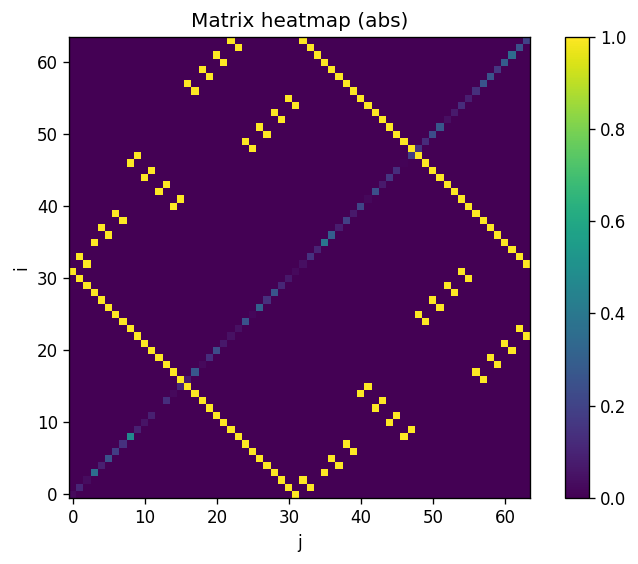

In [9]:
plot_matrix(H_best)